In [15]:
import numpy as np
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor



In [16]:
y_train = pl.read_csv("../data/raw/target_train.csv")   

print(y_train.describe())

shape: (9, 4)
┌────────────┬─────────┬───────────┬───────────┐
│ statistic  ┆ ID      ┆ OS_YEARS  ┆ OS_STATUS │
│ ---        ┆ ---     ┆ ---       ┆ ---       │
│ str        ┆ str     ┆ f64       ┆ f64       │
╞════════════╪═════════╪═══════════╪═══════════╡
│ count      ┆ 3323    ┆ 3173.0    ┆ 3173.0    │
│ null_count ┆ 0       ┆ 150.0     ┆ 150.0     │
│ mean       ┆ null    ┆ 2.480713  ┆ 0.504255  │
│ std        ┆ null    ┆ 2.588259  ┆ 0.500061  │
│ min        ┆ P100000 ┆ 0.0       ┆ 0.0       │
│ 25%        ┆ null    ┆ 0.652055  ┆ 0.0       │
│ 50%        ┆ null    ┆ 1.652055  ┆ 1.0       │
│ 75%        ┆ null    ┆ 3.572603  ┆ 1.0       │
│ max        ┆ P132729 ┆ 22.043836 ┆ 1.0       │
└────────────┴─────────┴───────────┴───────────┘


In [17]:
test = y_train.select("OS_STATUS" , "OS_YEARS")

In [18]:
test

OS_STATUS,OS_YEARS
f64,f64
1.0,1.115068
0.0,4.928767
0.0,2.043836
1.0,2.476712
0.0,3.145205
…,…
null,null
null,null
0.0,1.99726


In [19]:
# # OS STATUS => Event
# # OS YEARS => durations

# from lifelines import KaplanMeierFitter

 

# kmf = KaplanMeierFitter()

# kmf.fit(durations=test["OS_YEARS"] , event_observed=test["OS_STATUS"])


# kmf.plot_survival_function()
# plt.title('Kaplan-Meier Survival Curve')
# plt.xlabel('Time')
# plt.ylabel('Survival Probability')
# plt.grid(True)
# plt.show()


In [20]:
y_train.describe()

statistic,ID,OS_YEARS,OS_STATUS
str,str,f64,f64
"""count""","""3323""",3173.0,3173.0
"""null_count""","""0""",150.0,150.0
"""mean""",null,2.480713,0.504255
"""std""",null,2.588259,0.500061
"""min""","""P100000""",0.0,0.0
"""25%""",null,0.652055,0.0
"""50%""",null,1.652055,1.0
"""75%""",null,3.572603,1.0
"""max""","""P132729""",22.043836,1.0


In [21]:
def imputation_null_values(df , cl , estimator) :
    quant_vars = cl
    sub_df = df.select(quant_vars)

    # Convert to pandas
    sub_pd = sub_df.to_pandas()

    # Apply Model-Based Imputation (Random Forest)
    imputer = IterativeImputer(estimator=estimator, random_state=42)
    imputed_data = imputer.fit_transform(sub_pd)

    # 4. To Polars
    imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

    # 5. Replace nulls
    df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])
    
    return df


In [22]:
y_train = imputation_null_values(y_train, ["OS_YEARS" , "OS_STATUS"], estimator=RandomForestRegressor())

In [23]:
y_train.describe()

statistic,ID,OS_YEARS,OS_STATUS
str,str,f64,f64
"""count""","""3323""",3323.0,3323.0
"""null_count""","""0""",0.0,0.0
"""mean""",null,2.50111,0.482847
"""std""",null,2.530889,0.498465
"""min""","""P100000""",0.0,0.0
"""25%""",null,0.69863,0.0
"""50%""",null,1.808219,0.03
"""75%""",null,3.454795,1.0
"""max""","""P132729""",22.043836,1.0


In [24]:
y_train = y_train.with_columns(
    pl.when(pl.col("OS_STATUS") >= 0.48).then(1).otherwise(0).alias("OS_STATUS")
)

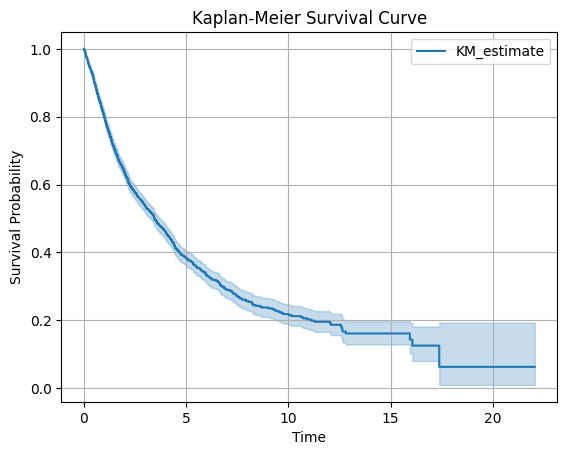

In [27]:
# OS STATUS => Event
# OS YEARS => durations

from lifelines import KaplanMeierFitter

 

kmf = KaplanMeierFitter()

kmf.fit(durations=y_train["OS_YEARS"] , event_observed=y_train["OS_STATUS"])


kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()


In [28]:
y_train = y_train.with_columns(
    pl.col("OS_STATUS").cast(pl.Boolean).alias("OS_STATUS")
)

In [29]:
y_train["OS_STATUS"].value_counts()

OS_STATUS,count
bool,u32
false,1723
true,1600


In [30]:
y_train = y_train.rename(
    {"OS_YEARS" : "time" ,
     "OS_STATUS" : "event"}
)

In [31]:
from sksurv.util import Surv

y_train_pd = y_train.to_pandas()

y_train_pd = Surv.from_dataframe('event' , 'time' , y_train_pd)

In [32]:
y_train_pd

array([( True, 1.11506849), (False, 4.92876712), (False, 2.04383562), ...,
       (False, 1.99726027), ( True, 0.09589041), (False, 2.29041096)],
      shape=(3323,), dtype=[('event', '?'), ('time', '<f8')])

In [33]:
y_train

ID,time,event
str,f64,bool
"""P132697""",1.115068,true
"""P132698""",4.928767,false
"""P116889""",2.043836,false
"""P132699""",2.476712,true
"""P132700""",3.145205,false
…,…,…
"""P121828""",2.932591,false
"""P121829""",2.932591,false
"""P121830""",1.99726,false


In [34]:
y_train_preprocess = y_train.write_csv("../data/processed/target_preprocess.csv")